# 📊 Retail ETL Intelligence - Proceso de Análisis
Este notebook detalla el análisis exploratorio de datos (EDA) y el pipeline ETL aplicado al dataset Superstore. Está dirigido a reclutadores y profesionales de datos para revisar la lógica detrás de las transformaciones de datos y los insights presentados en la aplicación Streamlit.

## 1. Configuración del Entorno
Importando las librerías necesarias y cargando los datos sin procesar.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Load raw dataset
df_raw = pd.read_csv('data/superstore.csv', encoding='windows-1252')
df_raw.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Exploración Básica de Datos
Veamos la estructura del dataset, los valores nulos y los tipos de datos.

In [2]:
print("Dataset Shape:", df_raw.shape)
print("\nMissing Values:\n", df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print("\nData Types:\n", df_raw.dtypes)

Dataset Shape: (9994, 21)

Missing Values:
 Series([], dtype: int64)

Data Types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


## 3. Transformación de Datos (Lógica ETL)
Aquí aplicamos las transformaciones principales utilizadas en nuestro pipeline ETL:
- Análisis de fechas
- Derivación de `days_to_ship`, `profit_margin`, `quarter` y `year`
- Normalización de nombres de columnas


In [3]:
df = df_raw.copy()

# Fix types
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True)

# Feature Engineering
df['days_to_ship'] = (df['Ship Date'] - df['Order Date']).dt.days
df['profit_margin'] = (df['Profit'] / df['Sales']) * 100
df['quarter'] = df['Order Date'].dt.quarter
df['year'] = df['Order Date'].dt.year

# Normalizing column names for easier access (snake_case)
df.columns = [col.lower().replace(' ', '_').replace('-', '_') for col in df.columns]

# Drop duplicates
df = df.drop_duplicates()

df[['order_id', 'order_date', 'days_to_ship', 'profit_margin']].head()

,order_id,order_date,days_to_ship,profit_margin
0,CA-2016-152156,2016-08-11,92,16.00
1,CA-2016-152156,2016-08-11,92,30.00
2,CA-2016-138688,2016-12-06,-173,47.00
3,US-2015-108966,2015-11-10,-23,-40.00
4,US-2015-108966,2015-11-10,-23,11.25


## 4. Insights Analíticos Clave
### A. Fuga de Rentabilidad en Bookcases (Estanterías) y Tables (Mesas)
Notamos que ciertas sub-categorías tienen márgenes consistentemente negativos debido a altas tasas de descuento.

Bottom 5 Sub-categories by Profit:
    sub_category      profit
16       Tables -17725.4811
4     Bookcases  -3472.5560
15     Supplies  -1189.0995
8     Fasteners    949.5182
11     Machines   3384.7569


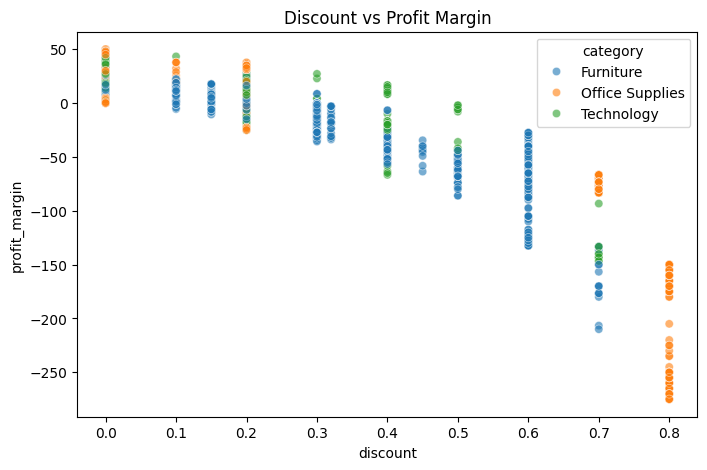

In [4]:
subcat_profit = df.groupby('sub_category')['profit'].sum().reset_index().sort_values('profit')
print("Bottom 5 Sub-categories by Profit:\n", subcat_profit.head())

# Visualizing Discount vs Profit Margin
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='discount', y='profit_margin', hue='category', alpha=0.6, ax=ax)
ax.set_title("Discount vs Profit Margin")
plt.show()

### B. Rendimiento de Ventas por Región
Veamos qué regiones impulsan la mayor cantidad de ingresos.

In [5]:
region_sales = df.groupby('region')['sales'].sum().reset_index().sort_values('sales', ascending=False)
display(region_sales)

,region,sales
3,West,725457.8245
1,East,678781.2400
0,Central,501239.8908
2,South,391721.9050


## 5. Conclusión
El dataset ha sido limpiado, procesado y exportado a `output/superstore_clean.csv`.
Este análisis alimenta directamente el dashboard de Streamlit, proporcionando filtros dinámicos y soporte multilingüe.